# t-SNE (t-Distributed Stochastic Neighbor Embedding)
## Module 2 - Dimensionality Reduction
Using the Iris dataset to demonstrate t-SNE visualization.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import os

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 1. Load & Preprocess the Iris Dataset

In [2]:
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names
feature_names = iris.feature_names

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Dataset shape:', X.shape)
print('Classes:', target_names)

Dataset shape: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']


## 2. What is t-SNE?
t-SNE is a **non-linear** dimensionality reduction technique particularly well-suited for **visualizing high-dimensional data**.
- It preserves **local structure** — nearby points in high-dim space stay nearby in 2D.
- Key hyperparameter: **perplexity** (typical range: 5–50).

## 3. Apply t-SNE (2D)

In [3]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

df_tsne = pd.DataFrame(X_tsne, columns=['Dim1', 'Dim2'])
df_tsne['species'] = [target_names[i] for i in y]

os.makedirs('../data', exist_ok=True)
df_tsne.to_csv('../data/iris_tsne.csv', index=False)
print('t-SNE result saved to data/iris_tsne.csv')

c:\Users\supev\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE result saved to data/iris_tsne.csv


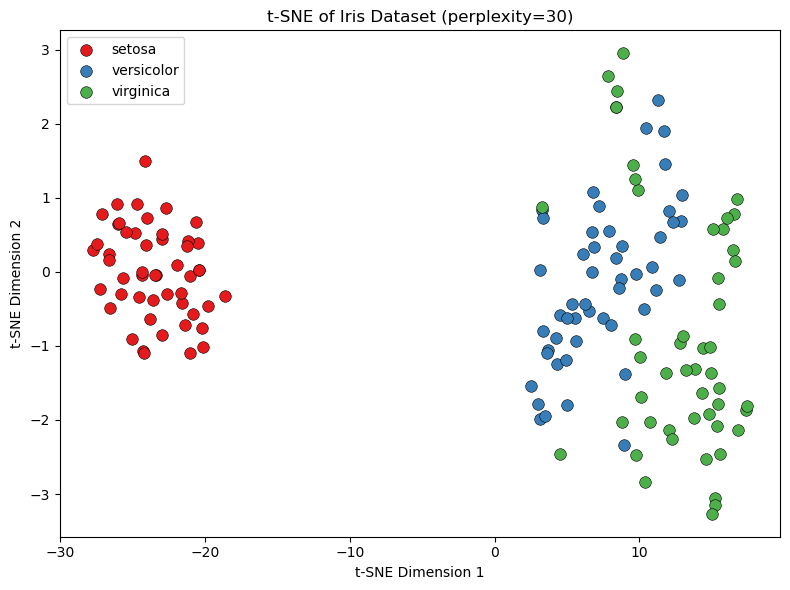

In [4]:
plt.figure(figsize=(8, 6))
colors = {'setosa': '#e41a1c', 'versicolor': '#377eb8', 'virginica': '#4daf4a'}
for species, grp in df_tsne.groupby('species'):
    plt.scatter(grp['Dim1'], grp['Dim2'], label=species, color=colors[species], s=70, edgecolors='k', linewidths=0.4)

plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('t-SNE of Iris Dataset (perplexity=30)')
plt.legend()
plt.tight_layout()
plt.savefig('../data/tsne_plot.png', dpi=150)
plt.show()

## 4. Effect of Perplexity

c:\Users\supev\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
c:\Users\supev\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
c:\Users\supev\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
c:\Users\supev\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


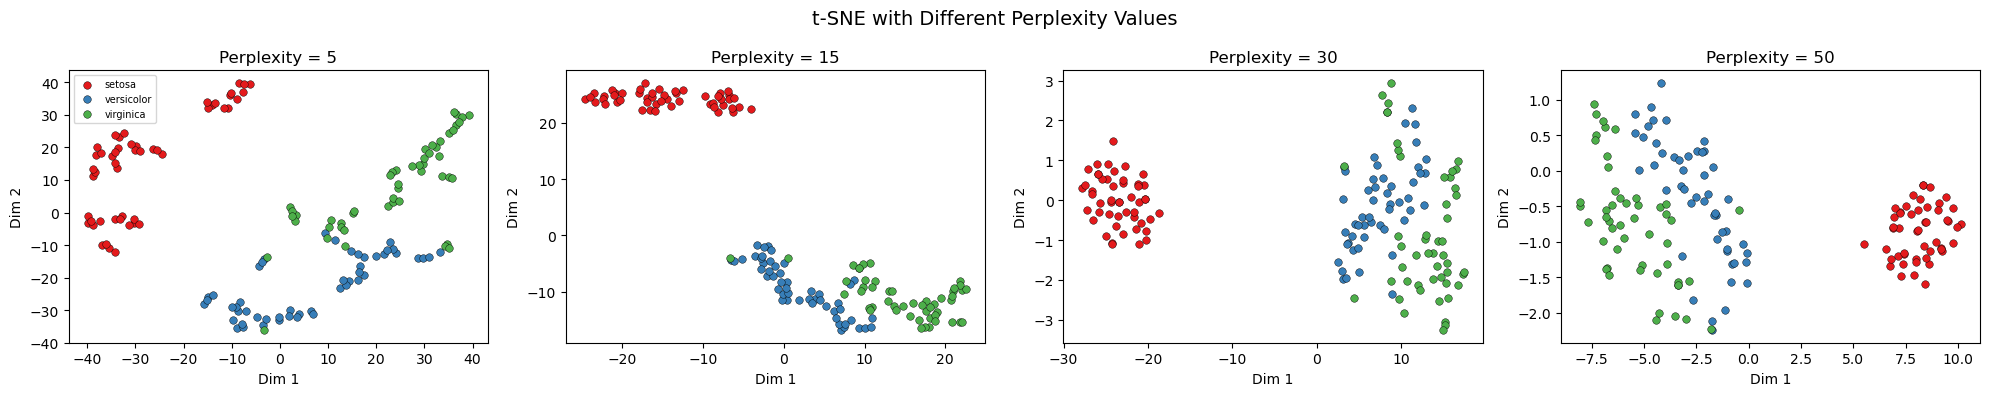

Perplexity comparison saved.


In [5]:
perplexities = [5, 15, 30, 50]
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, p in zip(axes, perplexities):
    tsne_p = TSNE(n_components=2, perplexity=p, random_state=42, n_iter=1000)
    X_p = tsne_p.fit_transform(X_scaled)
    for cls, color in zip(range(3), ['#e41a1c', '#377eb8', '#4daf4a']):
        mask = y == cls
        ax.scatter(X_p[mask, 0], X_p[mask, 1], c=color, label=target_names[cls], s=30, edgecolors='k', linewidths=0.3)
    ax.set_title(f'Perplexity = {p}')
    ax.set_xlabel('Dim 1')
    ax.set_ylabel('Dim 2')

axes[0].legend(fontsize=7)
plt.suptitle('t-SNE with Different Perplexity Values', fontsize=14)
plt.tight_layout()
plt.savefig('../data/tsne_perplexity_comparison.png', dpi=150)
plt.show()
print('Perplexity comparison saved.')

## 5. PCA vs t-SNE Comparison

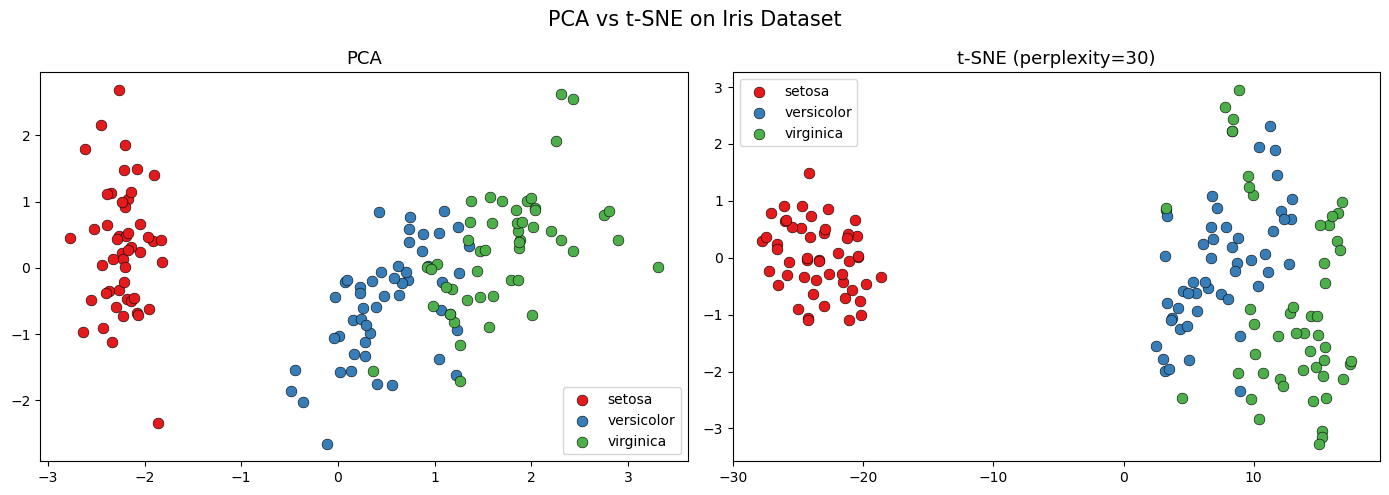

Comparison plot saved.


In [6]:
from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
titles = ['PCA', 't-SNE (perplexity=30)']
data_list = [X_pca, X_tsne]

for ax, title, data in zip(axes, titles, data_list):
    for cls, color, name in zip(range(3), ['#e41a1c', '#377eb8', '#4daf4a'], target_names):
        mask = y == cls
        ax.scatter(data[mask, 0], data[mask, 1], c=color, label=name, s=60, edgecolors='k', linewidths=0.4)
    ax.set_title(title, fontsize=13)
    ax.legend()

plt.suptitle('PCA vs t-SNE on Iris Dataset', fontsize=15)
plt.tight_layout()
plt.savefig('../data/pca_vs_tsne.png', dpi=150)
plt.show()
print('Comparison plot saved.')

## Summary
| Feature | PCA | t-SNE |
|---|---|---|
| Type | Linear | Non-linear |
| Preserves | Global variance | Local structure |
| Interpretable axes | Yes | No |
| Speed | Fast | Slower |
| Best for | Feature reduction | Visualization |

**Conclusion:** t-SNE separates all 3 Iris classes more cleanly than PCA visually, but PCA's components carry interpretable meaning.